# Infrastructure as Code with Ansible

**DD2482 executable tutorial · Week 5 · about 35–45 minutes**

Run the cells from top to bottom in a fresh **Google Colab** runtime. You need only a browser and a free Colab runtime. The notebook configures its own temporary VM; no cloud provider account, payment details, or local installation are required. A free Google account may be needed to use Colab. Colab may ask you to approve running a notebook from GitHub.

## Learning outcomes

By the end, you can explain desired state, idempotency, and drift; read an inventory and playbook; use variables and Jinja templates; deploy and test a Flask service behind Nginx; show that a second Ansible run changes nothing; repair manual drift; and decide when Ansible or a provisioning tool is appropriate.


## The system you will build

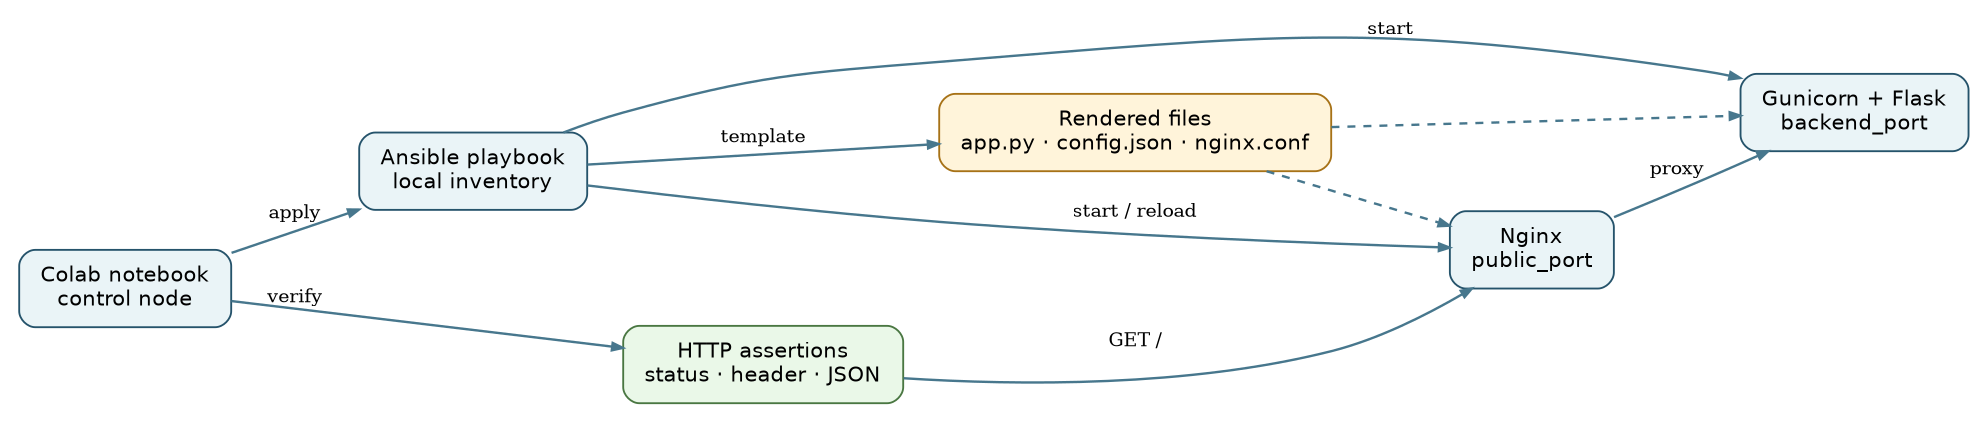

The notebook is the **control node**. Ansible uses a local inventory entry to manage the same Colab VM. Gunicorn serves the Flask application on the selected backend port. Nginx listens on the selected public port and proxies requests to it. The notebook prefers ports 8000 and 8080, but chooses free alternatives when either is occupied. Tests call port 8080, covering the full path. Both ports stay on localhost.


## 1. Why declare the desired state?

Hand-written server commands can be forgotten, reordered, or changed without a record. A playbook records the desired packages, files, and running processes. **Convergence** means applying it moves the machine toward that state. **Idempotency** means applying it again when the state already matches makes no further changes. **Configuration drift** is a manual change that makes the machine differ from the declaration. We will create drift, observe it, and repair it.


In [ ]:
import errno
import json
import os
import shutil
import socket
import subprocess
import sys
from pathlib import Path

WORK = Path('/content/dd2482-ansible-tutorial')
DEPLOY = WORK / 'deployed'
PORTS_FILE = WORK / 'ports.json'
assert os.geteuid() == 0, 'Use a standard Google Colab runtime (which runs as root).'
WORK.mkdir(parents=True, exist_ok=True)
# A check-mode preview cannot create parent directories. Bootstrap an empty
# directory here; the playbook still declares and manages its state.
DEPLOY.mkdir(parents=True, exist_ok=True)

def pid_is_alive(path):
    try:
        os.kill(int(path.read_text().strip()), 0)
        return True
    except (FileNotFoundError, ValueError, ProcessLookupError):
        return False

def port_is_free(port):
    # bind catches listeners on both 127.0.0.1 and 0.0.0.0.
    with socket.socket() as sock:
        try:
            sock.bind(('127.0.0.1', port))
            return True
        except OSError as error:
            if error.errno == errno.EADDRINUSE:
                return False
            raise

saved_ports = json.loads(PORTS_FILE.read_text()) if PORTS_FILE.exists() else {}

def choose_port(name, preferred, fallback_start, pid_name, excluded=()):
    previous = saved_ports.get(name)
    if (isinstance(previous, int) and 1 <= previous <= 65535
            and previous not in excluded
            and (port_is_free(previous) or pid_is_alive(DEPLOY / pid_name))):
        return previous
    for candidate in (preferred, *range(fallback_start, fallback_start + 100)):
        if candidate not in excluded and port_is_free(candidate):
            return candidate
    raise RuntimeError(f'No free port found for {name}.')

BACKEND_PORT = choose_port('backend', 8000, 38000, 'gunicorn.pid')
PUBLIC_PORT = choose_port('public', 8080, 48000, 'nginx.pid', (BACKEND_PORT,))
PORTS_FILE.write_text(json.dumps({'backend': BACKEND_PORT, 'public': PUBLIC_PORT}) + '\n')
print(f'Backend port: {BACKEND_PORT}; Nginx public port: {PUBLIC_PORT}')
if PUBLIC_PORT != 8080 or BACKEND_PORT != 8000:
    print('A default port was occupied, so free local ports were selected.')

subprocess.run(['apt-get', 'update', '-qq'], check=True)
subprocess.run(['apt-get', 'install', '-y', '-qq', 'nginx', 'python3-venv'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ansible'], check=True)
for command in ([sys.executable, '--version'], ['ansible-playbook', '--version'], ['nginx', '-v']):
    result = subprocess.run(command, text=True, capture_output=True, check=True)
    print((result.stdout or result.stderr).splitlines()[0])
print('Flask and Gunicorn will be installed into the application venv by Ansible.')


: 

## 2. Inventory and variables

The inventory says *which machine* to configure. `ansible_connection=local` avoids SSH and credentials. The variable file says *what deployment* we want. Keeping these values in one place makes a reviewed version update possible later.


In [ ]:
import textwrap

def write_source(name, content):
    path = WORK / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(textwrap.dedent(content).lstrip(), encoding='utf-8')
    print(path)

write_source('inventory.ini', f'''
[colab]
localhost ansible_connection=local ansible_python_interpreter={sys.executable}
''')
write_source('vars.yml', f'''
app_name: "dd2482-demo"
app_version: "1.0"
environment_name: "tutorial"
backend_port: {BACKEND_PORT}
public_port: {PUBLIC_PORT}
''')
print((WORK / 'inventory.ini').read_text())
print((WORK / 'vars.yml').read_text())


## 3. Templates for the application and proxy

Ansible's `template` task replaces Jinja expressions such as `{{ app_version }}` with variable values. The Flask route reads the rendered JSON config on every request, making both drift and repair visible immediately. Nginx adds a response header so the test can prove the request passed through the proxy.


In [ ]:
write_source('templates/app.py.j2', '''
import json
from pathlib import Path

from flask import Flask, jsonify

app = Flask(__name__)
CONFIG = Path("/content/dd2482-ansible-tutorial/deployed/config.json")

@app.get("/")
def index():
    return jsonify(json.loads(CONFIG.read_text(encoding="utf-8")))
''')
write_source('templates/config.json.j2', '''
{
  "application": "{{ app_name }}",
  "version": "{{ app_version }}",
  "environment": "{{ environment_name }}"
}
''')
write_source('templates/nginx.conf.j2', '''
pid /content/dd2482-ansible-tutorial/deployed/nginx.pid;
error_log /content/dd2482-ansible-tutorial/deployed/nginx-error.log;
events {}
http {
    access_log /content/dd2482-ansible-tutorial/deployed/nginx-access.log;
    server {
        listen 127.0.0.1:{{ public_port }};
        location / {
            proxy_pass http://127.0.0.1:{{ backend_port }};
            add_header X-DD2482-Proxy nginx always;
        }
    }
}
''')
for path in sorted((WORK / 'templates').glob('*')):
    print(f'\n{path.name}:\n{path.read_text()}')


## 4. The playbook

The playbook verifies OS packages, creates a Python venv, installs Flask and Gunicorn, renders three managed files, and starts the two services. Colab does not run `systemd`, so the playbook manages the tutorial's processes with PID files. Read-only process checks report `ok`; a service starts only when missing. A changed application template restarts Gunicorn, and a changed Nginx template reloads Nginx.


In [ ]:
write_source('playbook.yml', '---\n- name: Deploy the DD2482 web service on Colab\n  hosts: colab\n  gather_facts: false\n  vars_files:\n    - vars.yml\n  vars:\n    deploy_dir: /content/dd2482-ansible-tutorial/deployed\n    venv_dir: /content/dd2482-ansible-tutorial/deployed/venv\n  tasks:\n    - name: Verify required OS packages\n      ansible.builtin.apt:\n        name:\n          - nginx\n          - python3-venv\n        state: present\n\n    - name: Ensure deployment directory exists\n      ansible.builtin.file:\n        path: "{{ deploy_dir }}"\n        state: directory\n        mode: "0755"\n\n    - name: Inspect Python virtual environment\n      ansible.builtin.stat:\n        path: "{{ venv_dir }}/bin/python"\n      register: venv_python\n\n    - name: Create Python virtual environment\n      ansible.builtin.command:\n        cmd: "python3 -m venv {{ venv_dir }}"\n        creates: "{{ venv_dir }}/bin/python"\n\n    - name: Install application packages\n      ansible.builtin.pip:\n        name:\n          - Flask\n          - gunicorn\n        executable: "{{ venv_dir }}/bin/pip"\n        state: present\n      register: app_packages\n      when: not ansible_check_mode or venv_python.stat.exists\n\n    - name: Render Flask application\n      ansible.builtin.template:\n        src: templates/app.py.j2\n        dest: "{{ deploy_dir }}/app.py"\n        mode: "0644"\n      register: app_template\n\n    - name: Render application configuration\n      ansible.builtin.template:\n        src: templates/config.json.j2\n        dest: "{{ deploy_dir }}/config.json"\n        mode: "0644"\n\n    - name: Render Nginx configuration\n      ansible.builtin.template:\n        src: templates/nginx.conf.j2\n        dest: "{{ deploy_dir }}/nginx.conf"\n        mode: "0644"\n      register: nginx_template\n\n    - name: Check Gunicorn process\n      ansible.builtin.shell: >-\n        test -f {{ deploy_dir }}/gunicorn.pid &&\n        kill -0 "$(cat {{ deploy_dir }}/gunicorn.pid)"\n      register: gunicorn_probe\n      changed_when: false\n      failed_when: false\n      check_mode: false\n      when: not ansible_check_mode\n\n    - name: Stop Gunicorn after application or package change\n      ansible.builtin.shell: "kill $(cat {{ deploy_dir }}/gunicorn.pid)"\n      when:\n        - not ansible_check_mode\n        - gunicorn_probe.rc | default(1) == 0\n        - app_template.changed or app_packages.changed | default(false)\n\n    - name: Wait for old backend to stop\n      ansible.builtin.wait_for:\n        host: 127.0.0.1\n        port: "{{ backend_port }}"\n        state: stopped\n        timeout: 20\n      when:\n        - not ansible_check_mode\n        - gunicorn_probe.rc | default(1) == 0\n        - app_template.changed or app_packages.changed | default(false)\n\n    - name: Start Gunicorn when needed\n      ansible.builtin.shell: >-\n        nohup {{ venv_dir }}/bin/gunicorn\n        --bind 127.0.0.1:{{ backend_port }} --workers 1\n        --chdir {{ deploy_dir }} app:app\n        > {{ deploy_dir }}/gunicorn.log 2>&1 < /dev/null &\n        echo $! > {{ deploy_dir }}/gunicorn.pid\n      when:\n        - not ansible_check_mode\n        - gunicorn_probe.rc | default(1) != 0 or app_template.changed or app_packages.changed | default(false)\n\n    - name: Wait for backend\n      ansible.builtin.wait_for:\n        host: 127.0.0.1\n        port: "{{ backend_port }}"\n        timeout: 30\n      when: not ansible_check_mode\n\n    - name: Validate Nginx configuration\n      ansible.builtin.command: "nginx -t -c {{ deploy_dir }}/nginx.conf"\n      changed_when: false\n      when: not ansible_check_mode\n\n    - name: Check Nginx process\n      ansible.builtin.shell: >-\n        test -f {{ deploy_dir }}/nginx.pid &&\n        kill -0 "$(cat {{ deploy_dir }}/nginx.pid)"\n      register: nginx_probe\n      changed_when: false\n      failed_when: false\n      check_mode: false\n      when: not ansible_check_mode\n\n    - name: Start Nginx when needed\n      ansible.builtin.command: "nginx -c {{ deploy_dir }}/nginx.conf"\n      when:\n        - not ansible_check_mode\n        - nginx_probe.rc | default(1) != 0\n\n    - name: Reload Nginx after configuration change\n      ansible.builtin.command: "nginx -s reload -c {{ deploy_dir }}/nginx.conf"\n      when:\n        - not ansible_check_mode\n        - nginx_probe.rc | default(1) == 0\n        - nginx_template.changed\n\n    - name: Wait for public endpoint\n      ansible.builtin.wait_for:\n        host: 127.0.0.1\n        port: "{{ public_port }}"\n        timeout: 30\n      when: not ansible_check_mode\n')
print((WORK / 'playbook.yml').read_text())


## 5. Validate before applying

Syntax checking catches malformed YAML and Ansible tasks. `--check --diff` previews managed file changes without applying them. Tasks that require running processes are skipped during check mode; the diff is a prediction, not proof that the service works.


In [ ]:
import re

def run_ansible(*arguments):
    command = ['ansible-playbook', '-i', 'inventory.ini', *arguments, 'playbook.yml']
    result = subprocess.run(command, cwd=WORK, text=True, stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT)
    print(result.stdout)
    if result.returncode:
        raise RuntimeError(f'Ansible exited with status {result.returncode}')
    return result.stdout

run_ansible('--syntax-check')
run_ansible('--check', '--diff')


## 6. Apply the desired state

`changed` means Ansible modified the VM; `ok` means a task found the expected state. The first run should include changes. The play recap at the end summarizes both.


In [ ]:
first_recap = run_ansible()
assert re.search(r'changed=[1-9]\d*', first_recap), 'Expected the first deployment to change resources.'

for command in ([str(DEPLOY / 'venv/bin/python'), '-c',
                 'import importlib.metadata as m; print("Flask", m.version("Flask"))'],
                [str(DEPLOY / 'venv/bin/gunicorn'), '--version']):
    print(subprocess.run(command, text=True, capture_output=True, check=True).stdout.strip())


## 7. Verify the complete request path

These assertions contact Nginx on the public port selected during setup. The custom header proves that Nginx handled the response, and matching JSON proves the backend served the declared config. A broken deployment makes this cell fail.


In [ ]:
import json
import urllib.request

def verify(expected_version):
    with urllib.request.urlopen(f'http://127.0.0.1:{PUBLIC_PORT}/', timeout=10) as response:
        assert response.status == 200
        assert response.headers.get('X-DD2482-Proxy') == 'nginx'
        body = json.load(response)
    expected = {'application': 'dd2482-demo', 'version': expected_version,
                'environment': 'tutorial'}
    assert body == expected, f'Expected {expected}, got {body}'
    print('HTTP 200 via Nginx:', body)

verify('1.0')


## 8. Prove idempotency

Run the same playbook again without editing variables. Every managed resource already matches the declaration, so the recap must say `changed=0`. If it does not, a task is modifying the VM on every run.


In [ ]:
second_recap = run_ansible()
changes = re.findall(r'changed=(\d+)', second_recap)
assert changes and int(changes[-1]) == 0, f'Expected changed=0, got {changes}'
print('Idempotency confirmed: changed=0')


## 9. Introduce configuration drift

A manual edit to the *deployed* JSON changes the actual machine but leaves `vars.yml` unchanged. This simulates an undocumented server fix. The next HTTP response should reveal the drift.


In [ ]:
config_path = DEPLOY / 'config.json'
actual = json.loads(config_path.read_text())
actual['version'] = 'manual-edit'
config_path.write_text(json.dumps(actual, indent=2) + '\n')
with urllib.request.urlopen(f'http://127.0.0.1:{PUBLIC_PORT}/', timeout=10) as response:
    drifted = json.load(response)
assert drifted['version'] == 'manual-edit'
print('Drifted response:', drifted)


## 10. Preview and repair the drift

Check mode should show that `config.json` differs. Reapplying the playbook restores the declared value. The final assertion verifies the service itself, not only the Ansible recap.


In [ ]:
drift_preview = run_ansible('--check', '--diff')
assert 'manual-edit' in drift_preview and '1.0' in drift_preview, 'Expected config diff was not shown.'
repair_recap = run_ansible()
assert re.search(r'changed=[1-9]\d*', repair_recap), 'Expected Ansible to repair drift.'
verify('1.0')


## 11. Make a controlled update

Now change the **declared** version from `1.0` to `2.0`. Preview it, apply it, verify the new response, and repeat the playbook to confirm the new state is idempotent. Compare this with the unrecorded edit above.


In [ ]:
vars_path = WORK / 'vars.yml'
variables = vars_path.read_text()
if 'app_version: "1.0"' in variables:
    vars_path.write_text(variables.replace('app_version: "1.0"', 'app_version: "2.0"'))
else:
    assert 'app_version: "2.0"' in variables, 'Unexpected version in vars.yml'
update_preview = run_ansible('--check', '--diff')
assert '2.0' in update_preview, 'Expected the proposed version in the preview.'
run_ansible()
verify('2.0')
final_recap = run_ansible()
final_changes = re.findall(r'changed=(\d+)', final_recap)
assert final_changes and int(final_changes[-1]) == 0
print('Updated state is idempotent: changed=0')


## 12. Reflect

- **Why Ansible?** It describes packages, files, and process configuration on an existing machine. Inventory separates the target from the playbook; variables and templates avoid repeating deployment values.
- **Why test the endpoint?** A successful playbook can still leave a broken request path. Calling Nginx tests the proxy and app together.
- **Where does this model stop?** One temporary Colab VM has no redundancy, durable storage, service manager, or remote hosts. PID files here are a teaching workaround for Colab's lack of `systemd`. Production services would use a supervisor and more complete health checks.
- **What changes for remote machines?** Replace the local inventory entry with hostnames and SSH connection details, then manage credentials securely. Do not put secrets into playbooks or this notebook.
- **When use Terraform?** Terraform is suited to provisioning resources such as networks and VMs. Ansible can then configure packages and applications on those VMs.

**Think about it:** Which tasks reported `changed` during repair, and why did the following run report zero? What would happen if you edited `vars.yml` but never reapplied the playbook?


## 13. Clean up

This stops the tutorial's Gunicorn and Nginx processes and removes its files. Installed OS and Python packages remain cached in the temporary Colab VM. You can then rerun the notebook from the top.


In [ ]:
import signal
import time

nginx_config = DEPLOY / 'nginx.conf'
if pid_is_alive(DEPLOY / 'nginx.pid') and nginx_config.exists():
    subprocess.run(['nginx', '-s', 'stop', '-c', str(nginx_config)], check=True)
if pid_is_alive(DEPLOY / 'gunicorn.pid'):
    os.kill(int((DEPLOY / 'gunicorn.pid').read_text().strip()), signal.SIGTERM)
for pid_file in (DEPLOY / 'nginx.pid', DEPLOY / 'gunicorn.pid'):
    for _ in range(50):
        if not pid_is_alive(pid_file):
            break
        time.sleep(0.1)
shutil.rmtree(WORK)
print('Tutorial services stopped and working directory removed.')
